## 1. Imports and Settings

In [1]:
import os
from collections import Counter
from pathlib import Path
import re
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp")
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from wordcloud import WordCloud

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
BW_COLORS = ["#111111", "#666666", "#999999", "#D9D9D9"]
BW_HATCHES = ["///", "\\\\\\", "xx", "..", "++"]
BW_LINESTYLES = ["-", "--", "-.", ":"]
BW_MARKERS = ["o", "s", "^", "D"]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})
pd.set_option("display.max_colwidth", 160)

## 1.1 Helper Functions

In [2]:
def basic_text_eda(data, label_col="label", text_col="text"):
    """Create reusable text statistics for EDA."""
    eda_df = data.copy()
    eda_df[text_col] = eda_df[text_col].fillna("").astype(str)
    eda_df["char_count"] = eda_df[text_col].str.len()
    eda_df["word_count"] = eda_df[text_col].str.split().str.len()
    eda_df["unique_word_count"] = eda_df[text_col].str.lower().str.findall(r"[a-zA-Z]{2,}").map(lambda words: len(set(words)))
    eda_df["avg_word_length"] = eda_df[text_col].str.findall(r"[a-zA-Z]+").map(
        lambda words: np.mean([len(word) for word in words]) if words else 0
    )
    return eda_df


def add_bar_labels(ax):
    for patch in ax.patches:
        height = patch.get_height()
        if np.isnan(height):
            continue
        ax.annotate(
            f"{height:,.0f}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points",
        )


def show_label_distribution(data, label_col="label"):
    label_counts = data[label_col].value_counts().rename_axis(label_col).reset_index(name="count")
    label_counts["percentage"] = (label_counts["count"] / len(data) * 100).round(2)
    display(label_counts)

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(
        label_counts[label_col],
        label_counts["count"],
        color=["white", "#E6E6E6", "#BFBFBF", "#8C8C8C"][: len(label_counts)],
        edgecolor="black",
        linewidth=1.2,
    )
    for idx, bar in enumerate(bars):
        bar.set_hatch(BW_HATCHES[idx % len(BW_HATCHES)])
    ax.set_title("Class Distribution")
    ax.set_xlabel("")
    ax.set_ylabel("Number of records")
    ax.tick_params(axis="x", rotation=20)
    add_bar_labels(ax)
    ax.margins(y=0.15)
    plt.tight_layout()
    plt.show()


def plot_text_lengths(eda_df, label_col="label"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    labels = sorted(eda_df[label_col].dropna().unique())
    upper_chars = eda_df["char_count"].quantile(0.95)
    bins = np.linspace(0, upper_chars, 35)

    for idx, label_value in enumerate(labels):
        clipped_chars = eda_df.loc[eda_df[label_col] == label_value, "char_count"].clip(upper=upper_chars)
        axes[0].hist(
            clipped_chars,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=1.8,
            color=BW_COLORS[idx % len(BW_COLORS)],
            linestyle=BW_LINESTYLES[idx % len(BW_LINESTYLES)],
            label=str(label_value),
        )
    axes[0].set_title("Character Count Distribution (95th percentile clipped)")
    axes[0].set_xlabel("Characters")
    axes[0].set_ylabel("Density")
    axes[0].legend(title="Class")

    upper_words = eda_df["word_count"].quantile(0.95)
    box_data = [
        eda_df.loc[eda_df[label_col] == label_value, "word_count"].clip(upper=upper_words)
        for label_value in labels
    ]
    box = axes[1].boxplot(
        box_data,
        tick_labels=labels,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 1.5},
        boxprops={"edgecolor": "black", "linewidth": 1.2},
        whiskerprops={"color": "black"},
        capprops={"color": "black"},
        flierprops={
            "marker": "o",
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markersize": 3,
        },
    )
    for idx, patch in enumerate(box["boxes"]):
        patch.set_facecolor(["white", "#E6E6E6", "#BFBFBF", "#8C8C8C"][idx % 4])
        patch.set_hatch(BW_HATCHES[idx % len(BW_HATCHES)])
    axes[1].set_title("Word Count by Class (95th percentile clipped)")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Words")
    axes[1].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


def top_words_by_label(data, label_value, text_col="text", label_col="label", n=20):
    text = " ".join(data.loc[data[label_col] == label_value, text_col].dropna().astype(str).str.lower())
    words = re.findall(r"[a-zA-Z]{3,}", text)
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return pd.DataFrame(Counter(words).most_common(n), columns=["word", "count"])


def wordcloud_text(data, label_value, text_col="text", label_col="label"):
    text = " ".join(data.loc[data[label_col] == label_value, text_col].dropna().astype(str))
    return text.strip() if text.strip() else "empty"


def plot_word_clouds(data, text_col="text", label_col="label"):
    labels = sorted(data[label_col].dropna().unique())
    fig, axes = plt.subplots(1, len(labels), figsize=(7 * len(labels), 5))
    if len(labels) == 1:
        axes = [axes]

    stopwords = set(ENGLISH_STOP_WORDS)
    for idx, label_value in enumerate(labels):
        wc = WordCloud(
            width=900,
            height=500,
            background_color="white",
            stopwords=stopwords,
            max_words=120,
            collocations=False,
            random_state=RANDOM_STATE,
            color_func=lambda *args, **kwargs: BW_COLORS[idx % 3],
        ).generate(wordcloud_text(data, label_value, text_col=text_col, label_col=label_col))
        axes[idx].imshow(wc, interpolation="bilinear")
        axes[idx].set_title(f"Word Cloud: {label_value}")
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()


def plot_top_words(words_df, title, n=15):
    plot_df = words_df.head(n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(
        plot_df["word"],
        plot_df["count"],
        color="white",
        edgecolor="black",
        linewidth=1.0,
    )
    for idx, bar in enumerate(bars):
        bar.set_hatch(BW_HATCHES[idx % len(BW_HATCHES)])
    ax.set_title(title)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


def plot_model_comparison(results_df):
    metrics_to_plot = ["accuracy", "weighted_f1", "roc_auc"]
    plot_df = results_df.set_index("model")[metrics_to_plot]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(plot_df.index))
    width = 0.24

    for idx, metric in enumerate(metrics_to_plot):
        values = plot_df[metric].values
        bars = ax.bar(
            x + (idx - 1) * width,
            values,
            width=width,
            label=metric,
            color=["white", "#E6E6E6", "#BFBFBF"][idx],
            edgecolor="black",
            linewidth=1.0,
        )
        for bar in bars:
            bar.set_hatch(BW_HATCHES[idx % len(BW_HATCHES)])

    ax.set_title("Model Comparison")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=15, ha="right")
    ax.legend(title="Metric")
    plt.tight_layout()
    plt.show()


def plot_decision_tree_preview(tree_pipeline, max_depth=3):
    vectorizer = tree_pipeline.named_steps["tfidf"]
    tree_model = tree_pipeline.named_steps["model"]
    feature_names = vectorizer.get_feature_names_out()

    plt.figure(figsize=(18, 8))
    plot_tree(
        tree_model,
        max_depth=max_depth,
        feature_names=feature_names,
        class_names=[str(value) for value in tree_model.classes_],
        filled=False,
        rounded=False,
        fontsize=8,
    )
    plt.title(f"Decision Tree Preview (first {max_depth} levels)")
    plt.tight_layout()
    plt.show()


def evaluate_model(name, model, X_train, X_test, y_train, y_test, positive_label):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "weighted_precision": precision,
        "weighted_recall": recall,
        "weighted_f1": f1,
    }

    print(f"{name} classification report")
    report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True, zero_division=0)).T
    display(report)

    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Greys", values_format="d", xticks_rotation=30, colorbar=False)
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    if len(labels) == 2:
        try:
            classes = list(model.classes_)
            positive_index = classes.index(positive_label)
            if hasattr(model, "predict_proba"):
                y_score = model.predict_proba(X_test)[:, positive_index]
            elif hasattr(model, "decision_function"):
                decision_scores = model.decision_function(X_test)
                if np.ndim(decision_scores) == 1:
                    # For binary LinearSVC, positive scores correspond to classes_[1].
                    y_score = decision_scores if positive_index == 1 else -decision_scores
                else:
                    y_score = decision_scores[:, positive_index]
            else:
                y_score = (y_pred == positive_label).astype(int)

            y_test_binary = (y_test == positive_label).astype(int)
            metrics["roc_auc"] = roc_auc_score(y_test_binary, y_score)
            RocCurveDisplay.from_predictions(
                y_test_binary,
                y_score,
                name=name,
                color="black",
                linestyle="-" if name == "Linear SVM" else "--",
                marker="o" if name == "Linear SVM" else "s",
                markevery=0.1,
                linewidth=1.8,
            )
            plt.title(f"{name} ROC Curve")
            plt.tight_layout()
            plt.show()
        except ValueError:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    return metrics, model

## 2. Load Dataset

In [3]:
DATA_PATH = Path(r"/home/durgaumadev/Documents/MTech/Security for Data Science/phishing/Phishing_Emails.csv")
df_raw = pd.read_csv(DATA_PATH)

df = (
    df_raw[["Email Text", "Email Type"]]
    .rename(columns={"Email Text": "text", "Email Type": "label"})
    .copy()
)

df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].astype(str)

## 3. Basic Structure

In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())

print("\nData types and missing values")
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
}))

Shape: (18650, 2)

Columns: ['text', 'label']


,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are ve...",Safe Email
1,the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus v...,Safe Email
2,re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anit...,Safe Email
3,"\nHello I am your hot lil horny toy.\n I am the one you dream About,\n I am a very open minded person,\n Love to talk about and any subject.\n F...",Phishing Email
4,"software at incredibly low prices ( 86 % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subtract represent ....",Phishing Email



Data types and missing values


,dtype,missing,missing_pct
text,str,0,0.0
label,str,0,0.0


## 4. Class Balance

,label,count,percentage
0,Safe Email,11322,60.71
1,Phishing Email,7328,39.29


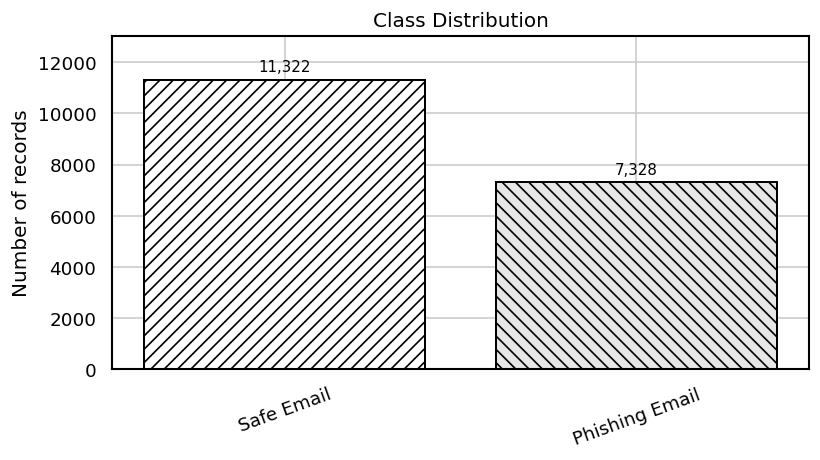

In [5]:
show_label_distribution(df, label_col="label")

## 5. Missing Values, Blank Text, and Duplicates

In [6]:
quality_summary = pd.DataFrame({
    "metric": [
        "rows",
        "missing_text",
        "blank_text",
        "missing_label",
        "duplicate_rows",
        "duplicate_texts",
    ],
    "value": [
        len(df),
        df["text"].isna().sum(),
        df["text"].fillna("").str.strip().eq("").sum(),
        df["label"].isna().sum(),
        df.duplicated().sum(),
        df["text"].duplicated().sum(),
    ],
})
display(quality_summary)

display(df[df["text"].duplicated(keep=False)].sort_values("text").head(10))

,metric,value
0,rows,18650
1,missing_text,0
2,blank_text,19
3,missing_label,0
4,duplicate_rows,1111
5,duplicate_texts,1112


,text,label
6821,,Phishing Email
3627,,Phishing Email
31,,Phishing Email
2049,,Phishing Email
3806,,Phishing Email
9999,,Phishing Email
6299,,Phishing Email
1883,,Phishing Email
11320,,Phishing Email
8594,,Phishing Email


## 6. Text Length Analysis

char_count                                                  \
                    count     mean        std  min    25%    50%      75%   
label                                                                       
Phishing Email     7328.0  1610.40    3349.38  0.0  353.0  731.0  1566.25   
Safe Email        11322.0  3493.01  160168.02  5.0  444.0  994.5  2029.75   

                           word_count          ... unique_word_count           \
                       max      count    mean  ...               75%      max   
label                                          ...                              
Phishing Email    129635.0     7328.0  301.19  ...             136.0  11472.0   
Safe Email      17036692.0    11322.0  685.87  ...             161.0  51944.0   

               avg_word_length                                            
                         count  mean   std   min   25%   50%   75%   max  
label                                                                     
Phishing Email          7328.0  4.84  0.87  0.00  4.42  4.77  5.10  26.0  
Safe Email             11322.0  4.75  0.56  2.18  4.35  4.66  5.05   9.0  

[2 rows x 32 columns]

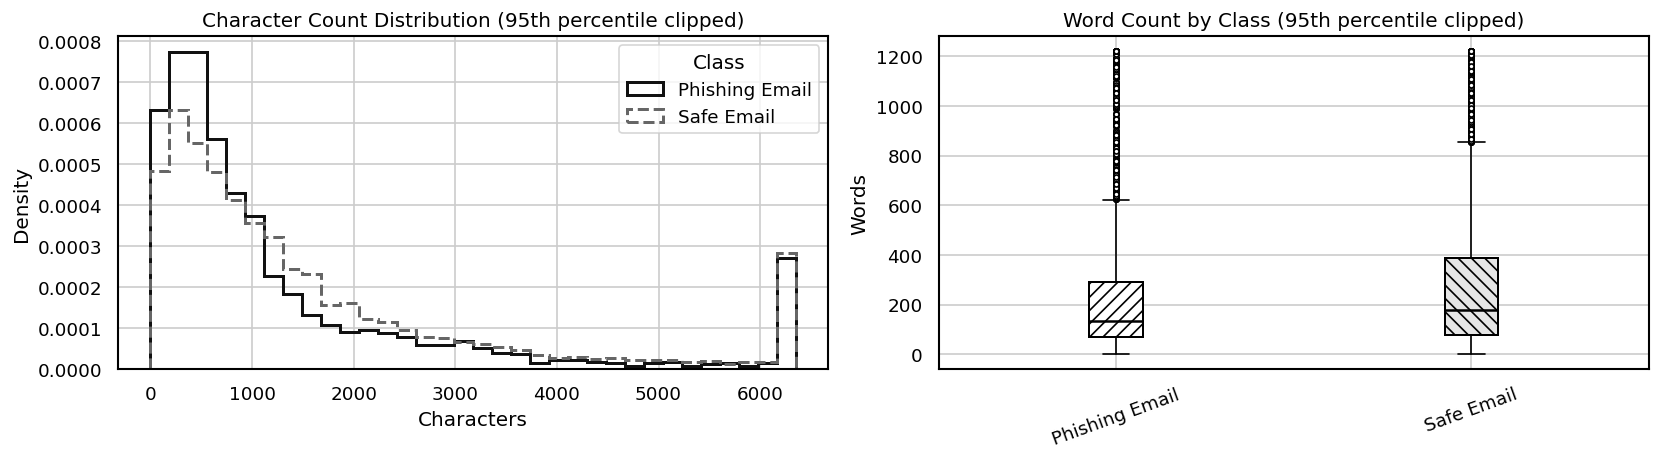

In [7]:
eda_df = basic_text_eda(df)

display(
    eda_df.groupby("label")[["char_count", "word_count", "unique_word_count", "avg_word_length"]]
    .describe()
    .round(2)
)

plot_text_lengths(eda_df)

## 7. Word Cloud Visualization

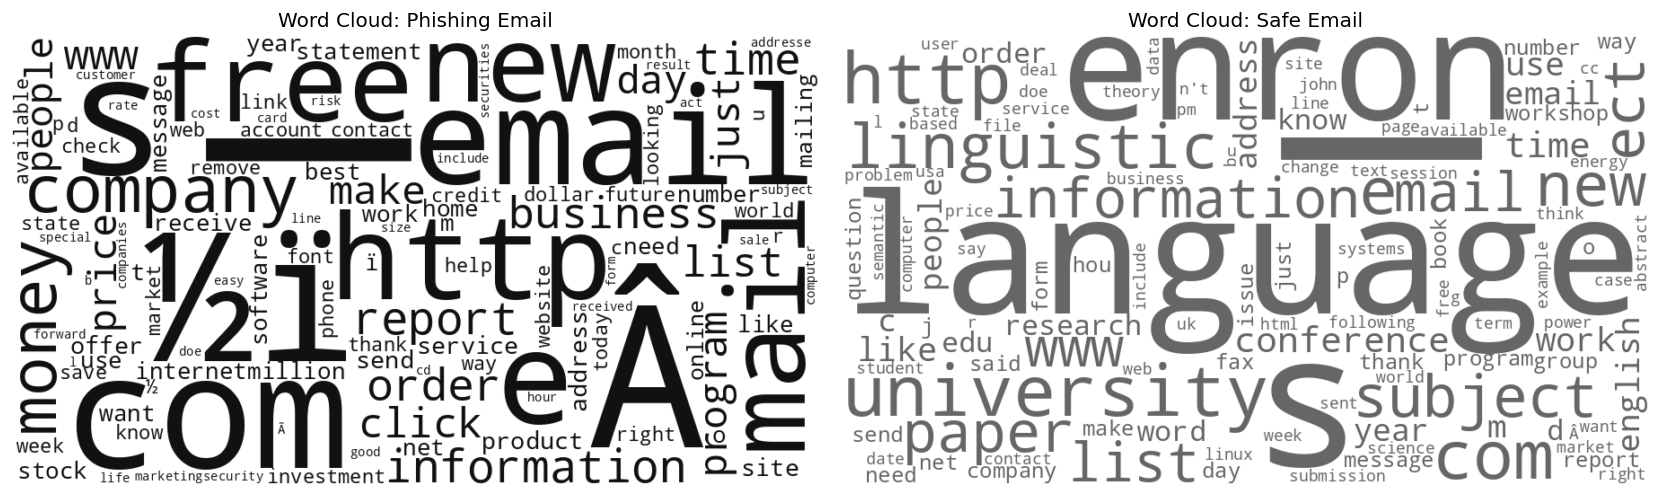

In [8]:
plot_word_clouds(df, text_col="text", label_col="label")

## 8. Most Frequent Words by Class

Top words for: Phishing Email


,word,count
0,com,6176
1,email,5418
2,http,4941
3,free,4533
4,mail,3983
5,money,3930
6,company,3915
7,information,3898
8,business,3623
9,time,3384


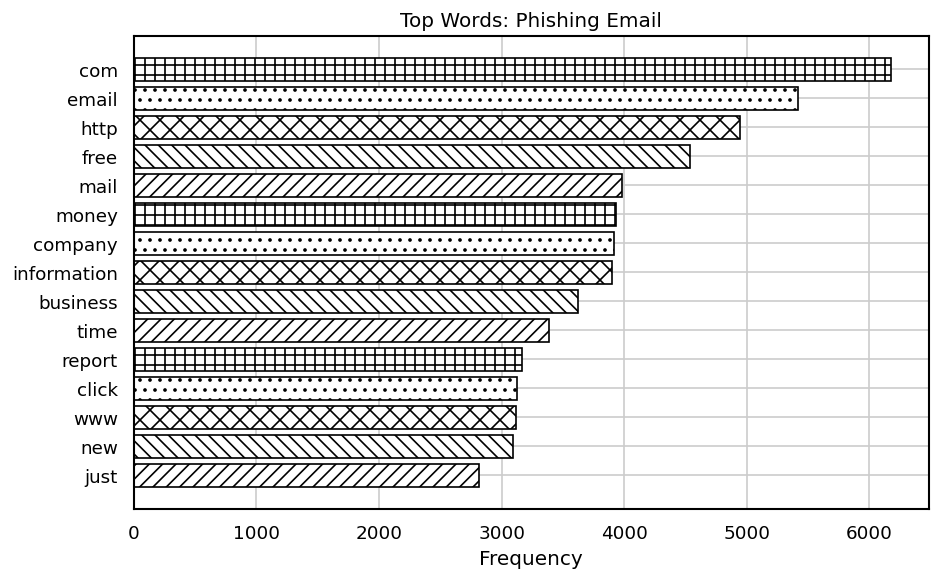

Top words for: Safe Email


,word,count
0,enron,19273
1,language,17221
2,university,17194
3,http,16210
4,com,15359
5,subject,11101
6,ect,11005
7,information,10866
8,www,10570
9,new,10418


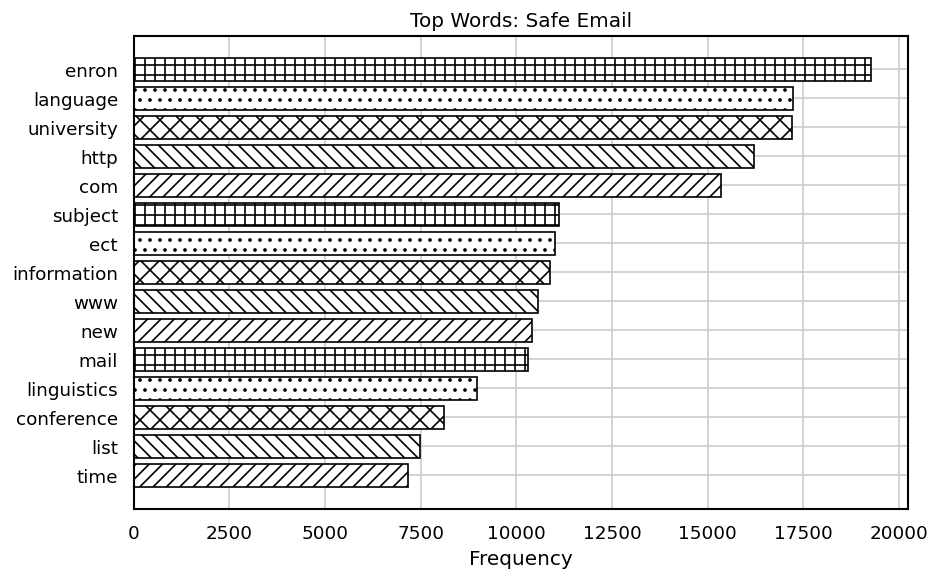

In [9]:
for label_value in sorted(df["label"].dropna().unique()):
    print(f"Top words for: {label_value}")
    words_df = top_words_by_label(df, label_value, n=20)
    display(words_df)
    plot_top_words(words_df, title=f"Top Words: {label_value}", n=15)

## 9. Text Representation Method

The text representation used for both models is **TF-IDF** using `TfidfVectorizer`.

TF-IDF means Term Frequency-Inverse Document Frequency. It converts text into numerical features by giving higher weight to words that are important in a document but not too common across the full dataset. This is a sparse vector representation, not a dense neural word embedding such as Word2Vec, GloVe, FastText, or BERT.

## 10. Prepare Data for Modeling

Rows after cleaning: 17536


,label,count,percentage
0,Safe Email,10979,62.61
1,Phishing Email,6557,37.39


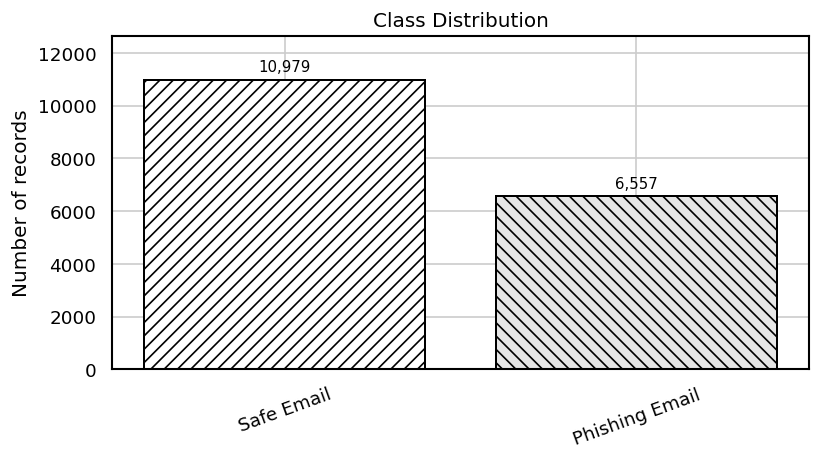

Train size: 14028
Test size: 3508


In [10]:
POSITIVE_LABEL = 'Phishing Email'

model_df = df.dropna(subset=["label"]).copy()
model_df["text"] = model_df["text"].fillna("").astype(str)
model_df = model_df[model_df["text"].str.strip().ne("")]
model_df = model_df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Rows after cleaning:", len(model_df))
show_label_distribution(model_df, label_col="label")

X = model_df["text"]
y = model_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

## 11. Support Vector Machine

Linear SVM classification report


,precision,recall,f1-score,support
Phishing Email,0.971386,0.983232,0.977273,1312.000000
Safe Email,0.989908,0.982696,0.986289,2196.000000
accuracy,0.982896,0.982896,0.982896,0.982896
macro avg,0.980647,0.982964,0.981781,3508.000000
weighted avg,0.982981,0.982896,0.982917,3508.000000


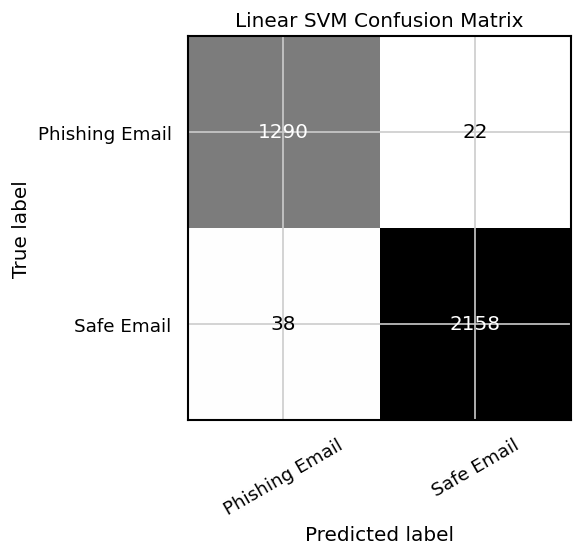

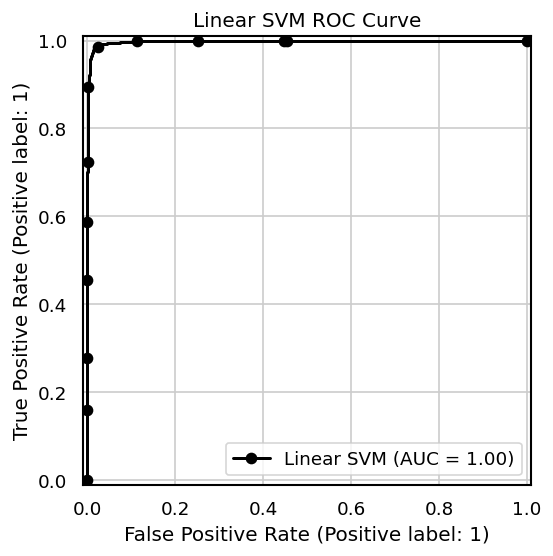

In [11]:
linear_svm = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=12000,
            ),
        ),
        (
            "model",
            LinearSVC(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                max_iter=5000,
            ),
        ),
    ]
)

results = []
trained_models = {}

metrics, trained_model = evaluate_model(
    "Linear SVM",
    linear_svm,
    X_train,
    X_test,
    y_train,
    y_test,
    positive_label=POSITIVE_LABEL,
)
results.append(metrics)
trained_models["Linear SVM"] = trained_model

## 12. Decision Tree

Decision Tree classification report


,precision,recall,f1-score,support
Phishing Email,0.833671,0.939787,0.883554,1312.000000
Safe Email,0.961065,0.887978,0.923077,2196.000000
accuracy,0.907355,0.907355,0.907355,0.907355
macro avg,0.897368,0.913882,0.903316,3508.000000
weighted avg,0.913419,0.907355,0.908295,3508.000000


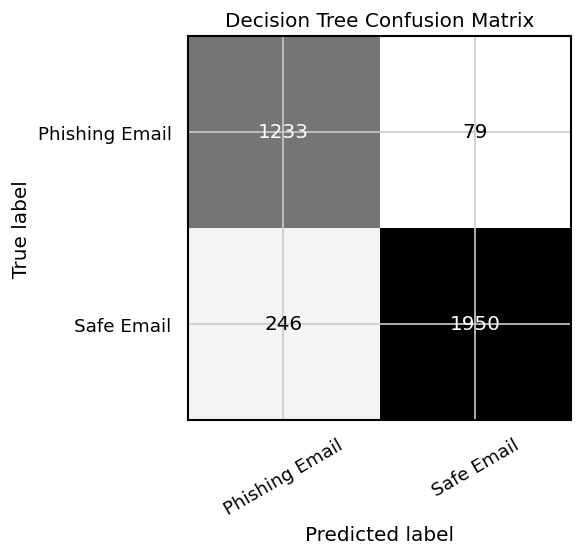

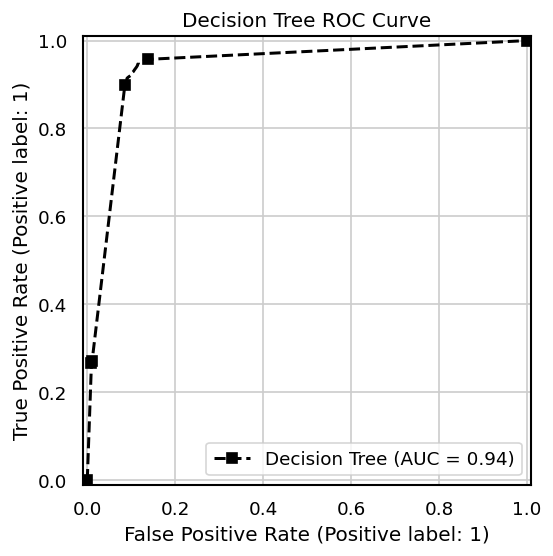

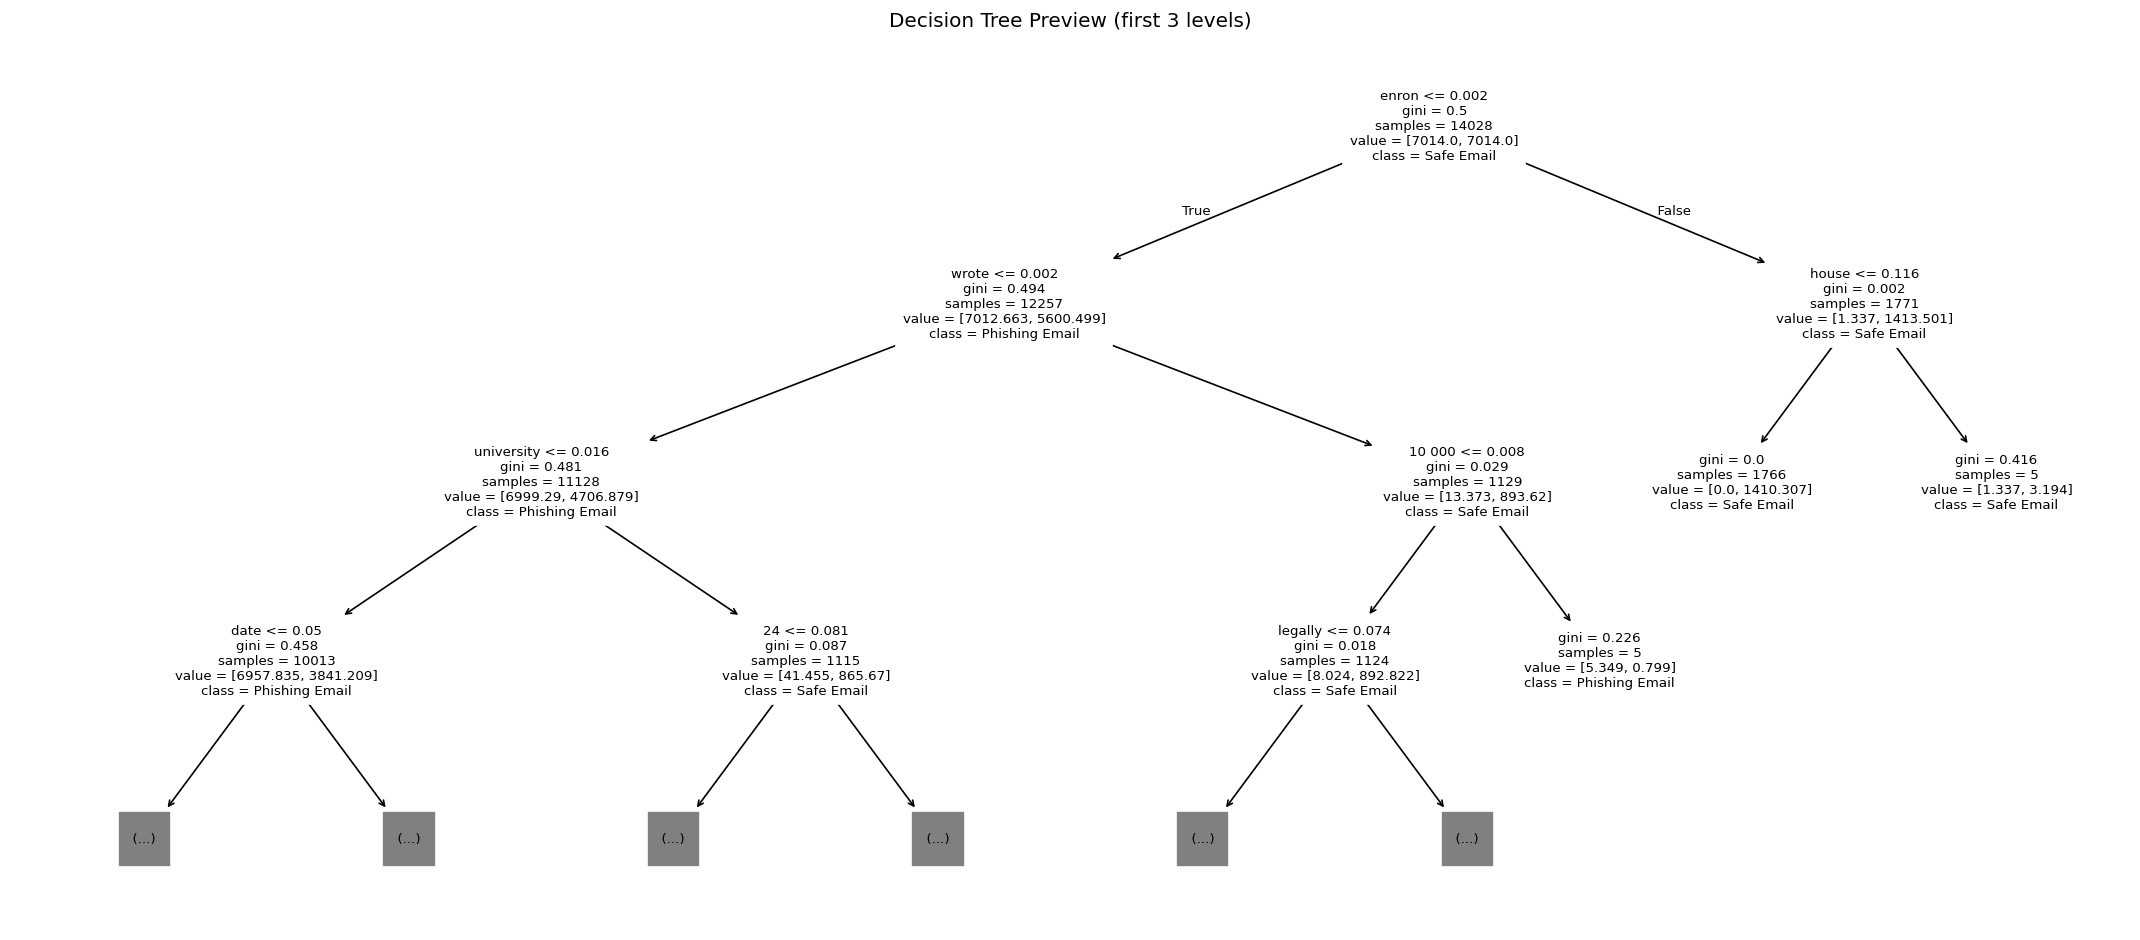

In [12]:
decision_tree = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=5000,
            ),
        ),
        (
            "model",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=40,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

metrics, trained_model = evaluate_model(
    "Decision Tree",
    decision_tree,
    X_train,
    X_test,
    y_train,
    y_test,
    positive_label=POSITIVE_LABEL,
)
results.append(metrics)
trained_models["Decision Tree"] = trained_model

plot_decision_tree_preview(trained_model, max_depth=3)

## 13. Model Comparison

,model,accuracy,weighted_precision,weighted_recall,weighted_f1,roc_auc
0,Linear SVM,0.9829,0.9830,0.9829,0.9829,0.9977
1,Decision Tree,0.9074,0.9134,0.9074,0.9083,0.9380


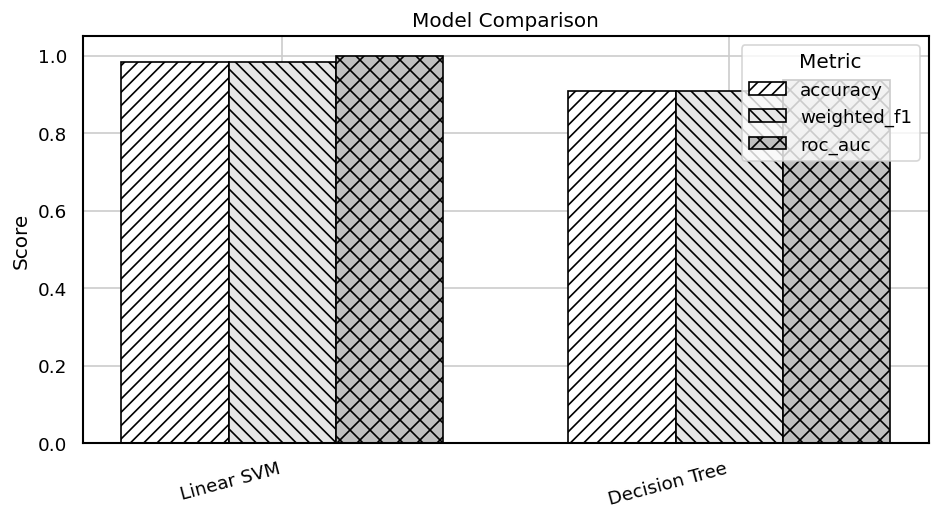

Best model by weighted F1: Linear SVM


In [13]:
results_df = pd.DataFrame(results).sort_values("weighted_f1", ascending=False).reset_index(drop=True)
display(results_df.round(4))
plot_model_comparison(results_df)

best_model_name = results_df.loc[0, "model"]
print(f"Best model by weighted F1: {best_model_name}")

## 14. Quick Error Check

In [14]:
best_model = trained_models[best_model_name]
y_pred = best_model.predict(X_test)

errors = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred,
})
errors = errors[errors["actual"] != errors["predicted"]]

print("Number of misclassified examples:", len(errors))
display(errors.head(15))

Number of misclassified examples: 60


,text,actual,predicted
9935,"\nForwarded-by: Nev Dull \nForwarded-by: ""Simondo"" Sean Connery was interviewed by Michael Parkinson, and bragged that\ndespite his 72 years of age, he coul...",Safe Email,Phishing Email
3452,"Hallo Xxxxxxxxx Yyyyyyy,HEUTE, 03. Juli, ist monatlicher Messetag der virtuellen 3D-Job-Messe!!\nIhre Chance, die Weichen fuer einen erfolgreichen Berufsein...",Safe Email,Phishing Email
9331,"\nA groys gesheft zol er hobn mit shroyre vus er hot, zol men bay im nit\nfregn, un vos men fregt zol er nisht hobn, and if that aint the truth\nnutin is.\n",Safe Email,Phishing Email
6917,nymex invitation - learn power trading power trading fundamentals : sept 15 - 16 nymex in nyc early bird discount now in effect ! nymex power delegates will...,Phishing Email,Safe Email
8769,"franz boas dear fellow linguists . i am a graduate student in taichung , taiwan . recently , i am interested in boas ' life , personality , and work . it is...",Safe Email,Phishing Email
10039,"london visit hi maureen how many days are you coming over for ? in addition to the couple of days you ' ll be spending at brook hunt , i can see one further...",Safe Email,Phishing Email
1819,"lacy ' s eye exam please respond to hi bubba ! lacy got her eye exam yesterday . he said that she is very near sighted , but the diabetes has not affected h...",Safe Email,Phishing Email
16238,pay less than enzye arkansan % rnd word gretings sigletos victory goes to the player who makes the next - to - last mistake . - chessmaster savielly grigori...,Phishing Email,Safe Email
4616,\nInteresting ebay item......(and no it wasnt me even though the spellingis\noddly familar)http://cgi.ebay.com/aw-cgi/eBayISAPI.dll?MfcISAPICommand=ViewItem...,Safe Email,Phishing Email
14249,chest pain or discomfort canadian generics suicide attempt or suicidal ideation http : / / www . inteemu . com / price . asp ? id = jnl,Phishing Email,Safe Email
